---
title: "DOW 5: Do shooting incidents occur near colleges and universities in Philadelphia?"
author: Emilie 
date: 3/23/2026
categories:
  - DOW
  - Shooting Incidents  
  - Philadelphia Universites/Colleges
---

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import geopandas as gpd

import warnings
warnings.simplefilter('ignore')

In [5]:
shoot_df = pd.read_csv('Data/shootings.csv') 

In [6]:
universities = pd.read_csv('Data/Universities_Colleges.csv')

# Do shootings incidents occur near colleges and universities in Philadelphia? 

![](images/city_philadelphia.jpeg){width=500}

#### Colleges and universities are often seen as safe spaces for students and people alike who are searching for their own hub inside a massive city. But being embedded in the massive framework of the city means busy streets, residential neighborhoods, and commercial districts. This means the attraction of many different kinds of people. In Philadelphia, where there are patterns of violence on a localized scale, it is important to see whether the violence (in this analysis, shooting incidents) also affects  specialized hubs like college campuses. It is important to analyze whether these colleges, supposedly considered "safe havens," have proximity to higher areas of risk. 

# Contextualizing the DATA 

## The total number of shooting incidents recorded in Philadelphia: 

In [10]:
print("The total number of shooting incidents recorded in Philadelphia:", len(shoot_df))

The total number of shooting incidents recorded in Philadelphia: 17516


## Shooting incidents recorded in Philadelphia per year: 

In [36]:
shoot_df.groupby('year').size()

year
2015    1294
2016    1342
2017    1265
2018    1447
2019    1473
2020    2259
2021    2342
2022    2269
2023    1672
2024    1112
2025     954
2026      87
dtype: int64

#### Just in 2025, 1 in 1,572 people were in shooting incidents in the city of Philadelphia. 

## Shooting incidents per year graphed

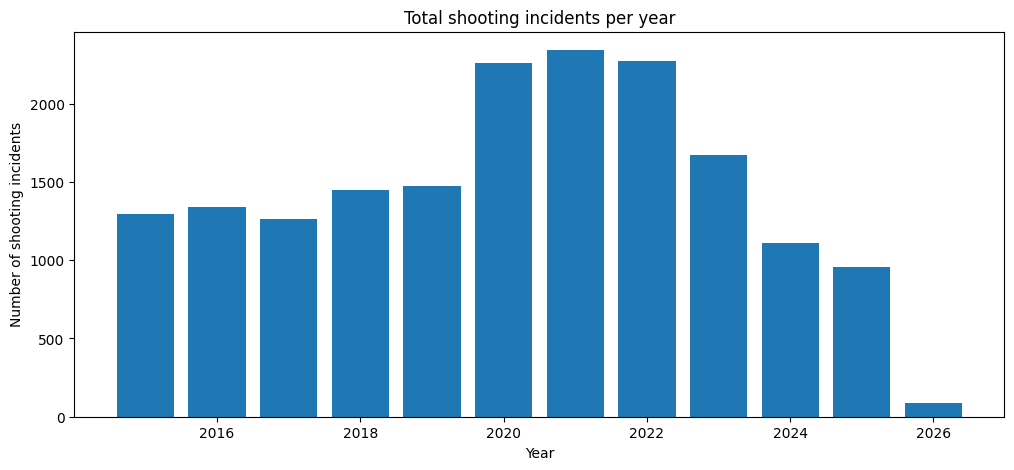

In [43]:
year_counts = shoot_df.groupby('year').size()

plt.figure(figsize=(12,5))
plt.bar(year_counts.index, year_counts.values)

plt.xlabel('Year')
plt.ylabel('Number of shooting incidents')
plt.title('Total shooting incidents per year')
plt.show()

### The shooting patterns reveal that between the years of 2015 to 2019, shooting incidents seemed remain at the same levels. However, beginning 2020, there was a sharp and sustained increase with the incidents peaking at over 2,300 in 2021. After this peak, shooting incidents gradually decreased. This pattern could be explained by the increase of allocated police budgets in the city of Philadelphia. 

## Victim ages of these shooting incidents graphed: 

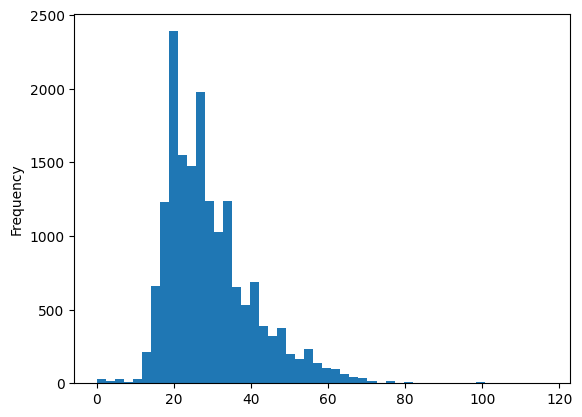

In [9]:
shoot_df['age'].plot(kind='hist', bins=50)
plt.show()

##### Most of the victims seem to fall in the 20-40 age range. 

## Victim races of these shooting incidents graphed: 

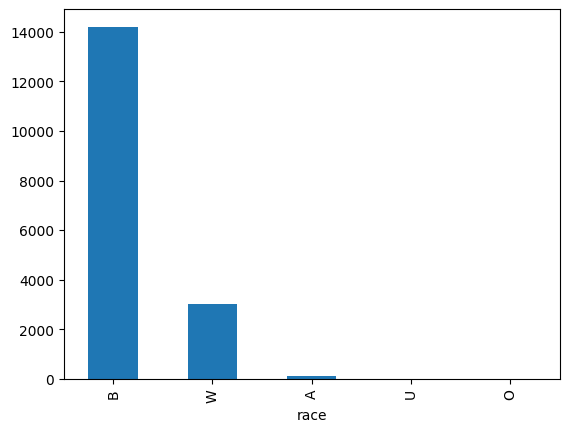

In [14]:
shoot_df['race'].value_counts().plot(kind='bar')
plt.show()

##### Most of the victims seem to be either Black or White. 

# Introducing Universities:

![](images/upenn.png){width=800}

In [16]:
import geopandas as gpd

universities_gpd = gpd.read_file('data/Universities_Colleges.geojson')

In [17]:
shootings_gdf = gpd.GeoDataFrame(
    shoot_df,
    geometry=gpd.points_from_xy(shoot_df['lng'], shoot_df['lat']),
    crs='EPSG:4326'
)

In [18]:
universities_coordinates = universities_gpd.to_crs(epsg=3857)
shootings_coordinates = shootings_gdf.to_crs(epsg=3857)

In [19]:
university_buffers = universities_coordinates.copy()
university_buffers['geometry'] = university_buffers.geometry.buffer(800)

In [20]:
shoot_combine = gpd.sjoin(shootings_coordinates, university_buffers)

In [24]:
shoot_combine_unique = shoot_combine.drop_duplicates(subset='dc_key')

In [30]:
top_universities = (shoot_combine_unique.groupby('name').size().sort_values(ascending=False))

## The Top 15 universities with the most shooting incidents: 

![](images/temple.jpg){width=500}

#### These are the top 15 universities with the most shooting incidents in total as recorded: 

In [31]:
top_universities.head(15)

name
Temple University Medical                       1240
Temple University                                751
Philadelphia College of Osteopathic Medicine     503
La Salle University                              480
University of Pennsylvania                       335
Community College of Philadelphia                168
Drexel University                                157
University of the Arts                            84
JNA School of Culinary Arts                       53
Thomas Jefferson University                       48
University of the Sciences in Philadelphia        44
Lutheran Theological Seminary                     12
Philadelphia University                           11
Saint Joseph's University                         10
Holy Family University                             4
dtype: int64

## Top 5 Universites with the most shooting incidents graphed: 

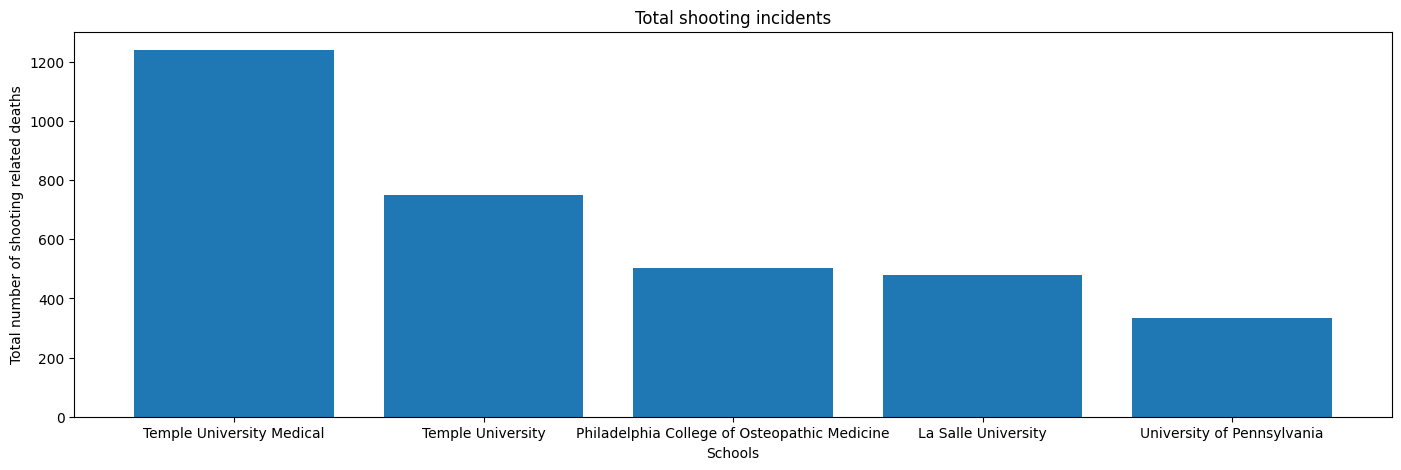

In [37]:
top5 = top_universities.head(5)
plt.figure(figsize=(17,5))
plt.bar(top5.index, top5.values) 
plt.xlabel('Schools')
plt.ylabel('Total number of shooting related deaths')
plt.title('Total shooting incidents')
plt.show()

### As seen Temple University Medical and Temple University have the most amount of shootings accounted for, this could be explained by both campuses being located in North Philadelphia where shooting incidents are more densely concentrated. The high number of shooting incidents reflect broader neighborhood patterns than the safety of the university itself. 

# BUT.... 

In [41]:
shoot_df['near_university'] = shoot_df.index.isin(shoot_combine.index)

shoot_df['near_university'].value_counts()

near_university
False    13181
True      4335
Name: count, dtype: int64

![](images/32%.png){width=800}

## Only about 32% of the total shooting incidents in Philadelphia occur near University campuses. 

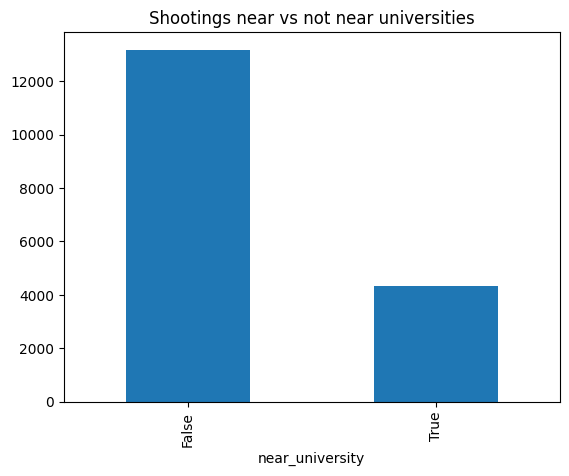

In [43]:
shoot_df['near_university'].value_counts().plot(kind='bar')
plt.title('Shootings near vs not near universities')
plt.show()

In [51]:
zip_gpd=gpd.read_file('data/Zipcodes_Poly.geojson').to_crs(crs=4326)

## Visualization of shootings and university locations:

### Red indicates the isolated shooting incidents and the blue represents the university locations

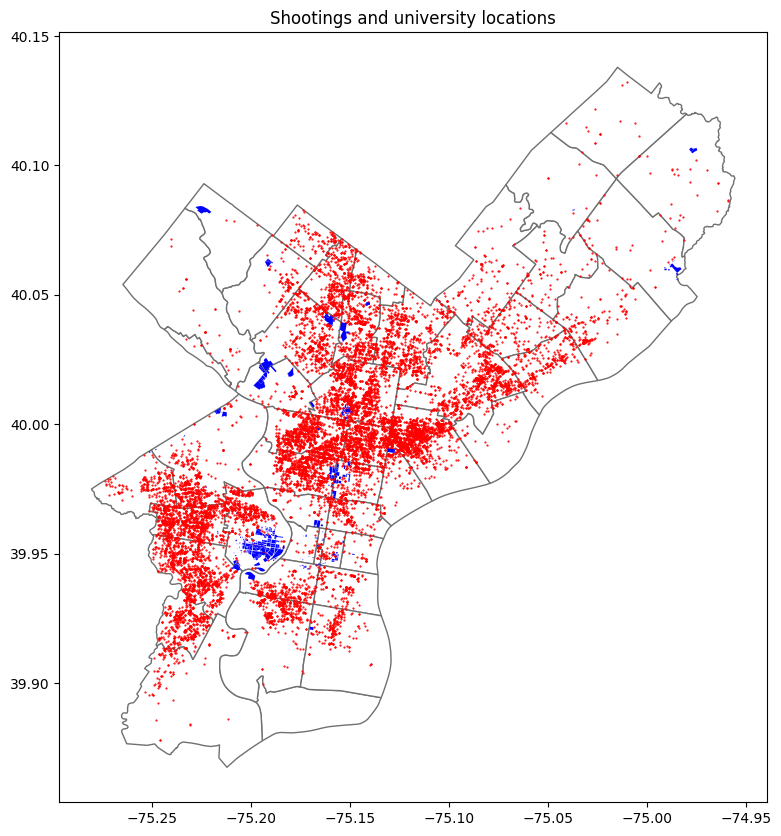

In [63]:
base = zip_gpd.plot(color='white', edgecolor='#707070', figsize=(10,10))
shootings_gdf.plot(ax=base, color='red', markersize=0.3)
universities_gpd.plot(ax=base, color='blue', markersize=30)
plt.title('Shootings and university locations')
plt.show()

![](images/conclusion.png){width=500}

## Conclusion: 

### Shooting incidents do occur near universities and colleges, but the data seen seems to suggest that most of the incidents are not aggregated near college campuses but spread throughout the city of Philadelphia. We can reasonably infer that there are more neighborhood dymanics at play here. Approximately 32% of all recorded shooting incidents took place within 800 meters of a university campus, indicating that these areas are not isolated from citywide patterns of violence.

### However, top shooting incident schools like Temple University and its medical campus are already located in areas of Philadelphia where shootings are densely concentrated. The proximity to shootings are not necessarily a reflection of the school's safety itself but the existing patterns of violence already present in the area there. Also, we can see that shooting incidents peaked in the years of 2020 and 2022 which indicates that there are broader trends in the city of Philadelphia. 

### Overall, although colleges and universities are seen as safe spaces, they are still embedded into a larger city. As a result, the surrounding safety conditions are not shaped by the school itself, but also by neighborhood and city dynamics. 